## Question 3

### **Radial Metallicity Relations in Simulations**

In [2]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.optimize import curve_fit

*The radial metallicity relation describes the change of metallicity – here the gas-phase metallicity A(O) = log10(N_O/N_H) + 12 – with galactocentric cylindrical radius RGal.
. Radial
metallicity gradients provide insight into processes such as inside-out formation, gas accretion, outflows, and radial migration. A lot of work has been done through observational
studies (e.g. Ho et al., 2017, ApJ, 846, 39) and a few simulations (e.g. Grand et al., 2016,
MNRAS, 460, 94), but more works is needed to understand variations of the radial metallicity
gradient.*

*Your colleague has completed a cosmological simulation of a Milky-Way-like spiral galaxy.
The FITS file data/nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits
contains the gas-phase metallicity A(O) and (x, y, z) positions of gas particles within RGal. = sqrt(x^2+y^2) < 25 kpc. Perform the following tasks and save your figures in figures/:*

1.

*Plot a two-panel figure:*

*-(a) logarithmic density plot of RGal. vs. A(O), with a linear fit and legend;*

*-(b) residuals of the fit, RGal. vs. ∆A(O).*

In [67]:
data = fits.open('data/nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits')[1].data
# data is in columns [x, y, z, A_O]

x = data['x']
y = data['y']
z = data['z']
A_O = data['A_O']

R_gal = np.sqrt(x**2 + y**2)

In [70]:
import matplotlib.colors as colors

3007047515.py: Linear fit parameters: m = -0.0342 ± 0.0000, p = 9.1278 ± 0.0002


/tmp/ipykernel_63281/3007047515.py:18: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axs[0].legend(loc='lower left')


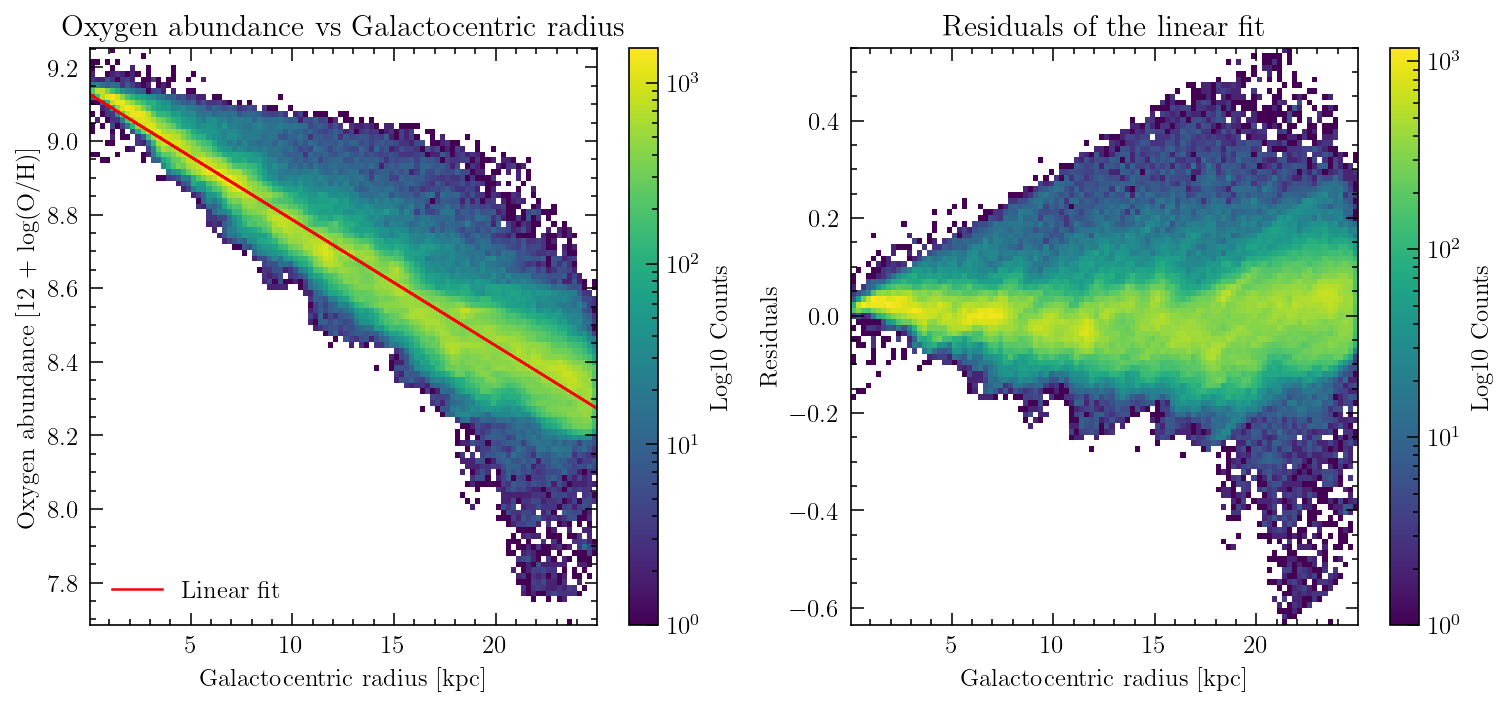

In [83]:
# two-panel figure
# a) logarithmic density plot of A_O vs R_gal, with a linear fit and legend
# b) residuals of the fit

def linear_func(x, m, p):
    return m * x + p
pcof, pcov = curve_fit(linear_func, R_gal, A_O)
pcor = np.sqrt(np.diag(pcov))
print(f"Linear fit parameters: m = {pcof[0]:.4f} ± {pcor[0]:.4f}, p = {pcof[1]:.4f} ± {pcor[1]:.4f}")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].hist2d(R_gal, A_O, bins=100, norm=colors.LogNorm(), cmap='viridis', label='Simulation data')
plt.colorbar(axs[0].collections[0], label='Log10 Counts')
axs[0].set_xlabel('Galactocentric radius [kpc]')
axs[0].set_ylabel('Oxygen abundance [12 + log(O/H)]')
axs[0].set_title('Oxygen abundance vs Galactocentric radius')
axs[0].plot(R_gal, linear_func(R_gal, *pcof), 'r-', label='Linear fit')
axs[0].legend(loc='lower left')

axs[1].hist2d(R_gal, A_O - linear_func(R_gal, *pcof), bins=100, norm=colors.LogNorm(), cmap='viridis')
axs[1].set_xlabel('Galactocentric radius [kpc]')
axs[1].set_ylabel('Residuals')
axs[1].set_title('Residuals of the linear fit')

plt.colorbar(axs[1].collections[0], label='Log10 Counts')
fig.savefig('figures/metallicity_radius.pdf', dpi=300)
fig.show()

2.

*Use a python fitting tool to fit a linear function to the data, reporting the intercept and
slope with uncertainties. Include any hyperparameters used.*

In [90]:
print(f"Linear fit parameters (A_O = m R_gal + p):")
print(f"m = {pcof[0]:.5f} ± {pcor[0]:.5f}")
print(f"p = {pcof[1]:.4f} ± {pcor[1]:.4f}")
print("No hyperparameters were used.")

2945239836.py: Linear fit parameters (A_O = m R_gal + p):
2945239836.py: m = -0.03420 ± 0.00001
2945239836.py: p = 9.1278 ± 0.0002
2945239836.py: No hyperparameters were used.


3.

*Discuss where the linear model fits well and where it does not. Use statistical metrics, such as the root mean square or another goodness-of-fit indicator, to quantify its
performance overall and in regions with larger residuals.*

4.

*Plot a three-panel figure for the x vs. y plane using the same bins and sensible colormaps:*

*• (a) 2D histogram of the median simulated A(O);*

*• (b) 2D histogram of the median fitted A(O);*

*• (c) 2D histogram of the median residuals ∆A(O).*

5.

6.